# Figure 4: Map of Western US power plants locations 2055 under four projected futures

**NOTE:** To run this notebook, the `prepare_data.ipynb` must first be run and all prerequisite data must be downloaded.

### Imports

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import os

### Data Paths

In [2]:
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'figures')

power_plant_fn = os.path.join(data_dir, 'clustered_power_plants_2055.geojson')
state_fn = os.path.join(data_dir, 'cb_2024_us_state_500k/cb_2024_us_state_500k.shp')
north_america_fn = os.path.join(data_dir, 'PoliticalBoundaries_Shapefile/NA_PoliticalDivisions/data/bound_p/boundaries_p_2021_v3.shp')
bathymetry_fn = os.path.join(data_dir, 'bathymetry_basemap.geojson')
transmission_fn = os.path.join(data_dir, 'US_Electric_Power_Transmission_Lines_5037807202786552385.geojson')

### Settings

In [3]:
color_dict = {
                'Geothermal':'#ad1b0a',
                'Solar':'#F7B615', 
                'Wind':'#95C060',
                'Wind (Offshore)': 'teal',
                'Biomass':'#e30787', 
                'Hydroelectric':'#2B7F9E', 
                'Nuclear': '#813f99', 
                'Petroleum':'#d9c7a9', 
                'Natural Gas':'#f08d02',
                'Coal':'#363636',
}

In [4]:
# read in prepared power plant data
data = gpd.read_file(power_plant_fn)

# state boundary shapefile
state = gpd.read_file(state_fn).to_crs('ESRI:102003')
wecc_states = ['CA', 'OR', 'WA', 'MT', 'ID', 'WY', 'UT', 'NV', 'AZ', 'NM', 'CO']
wecc = state[state.STUSPS.isin(wecc_states)].copy()
xMin, yMin, xMax, yMax = wecc.dissolve().envelope.buffer(100000, join_style='mitre').total_bounds

# north america shapefile
north_america = os.path.join(north_america_fn)
na_shape = gpd.read_file(north_america).to_crs('ESRI:102003')
na_shape = na_shape[na_shape.COUNTRY.isin(['MEX', 'CAN'])]
na_shape = na_shape.dissolve()
na_shape2 = gpd.clip(na_shape,  wecc.dissolve().envelope.buffer(100000, join_style='mitre'))

# bathymetry shapefile
basemap = gpd.read_file(bathymetry_fn)
basemap_wecc = gpd.clip(basemap, wecc.dissolve().envelope.buffer(100000, join_style='mitre'))

# transmission shapefile
transmission = gpd.read_file(transmission_fn)
transmission = gpd.clip(transmission, wecc.to_crs(transmission.crs))
transmission = transmission.to_crs('ESRI:102003')
transmission_230 = transmission[transmission.VOLTAGE >= 230].copy()

In [6]:
# line legend
transmission_legend = Line2D([0], [0], color='black', lw=1, linestyle='dashed', label='Transmission Lines ≥230 kV')
state_boundary = Line2D([0], [0], color='black', lw=1, label='US State Boundaries')
boundary_legend_elements = [ transmission_legend, state_boundary ]

timestep = 2055 

# color legend
legend_elements = []
for tech in ['Coal', 'Hydroelectric','Natural Gas', 'Solar', 'Wind', 'Biomass']:
    tech_patch = mpatches.Patch(facecolor=color_dict[tech], label=tech, edgecolor='black', lw=.75)
    legend_elements.append(tech_patch)

## ccs legend
non_ccs = Line2D([0], [0], lw=0, label='Without CCS', marker='o', markersize = 8, markerfacecolor='white', markeredgecolor='black')
legend_elements.append(non_ccs)
ccs = Line2D([0], [0], lw=0, label='With CCS', marker='D', markersize = 8, markerfacecolor='white', markeredgecolor='black')
legend_elements.append(ccs)

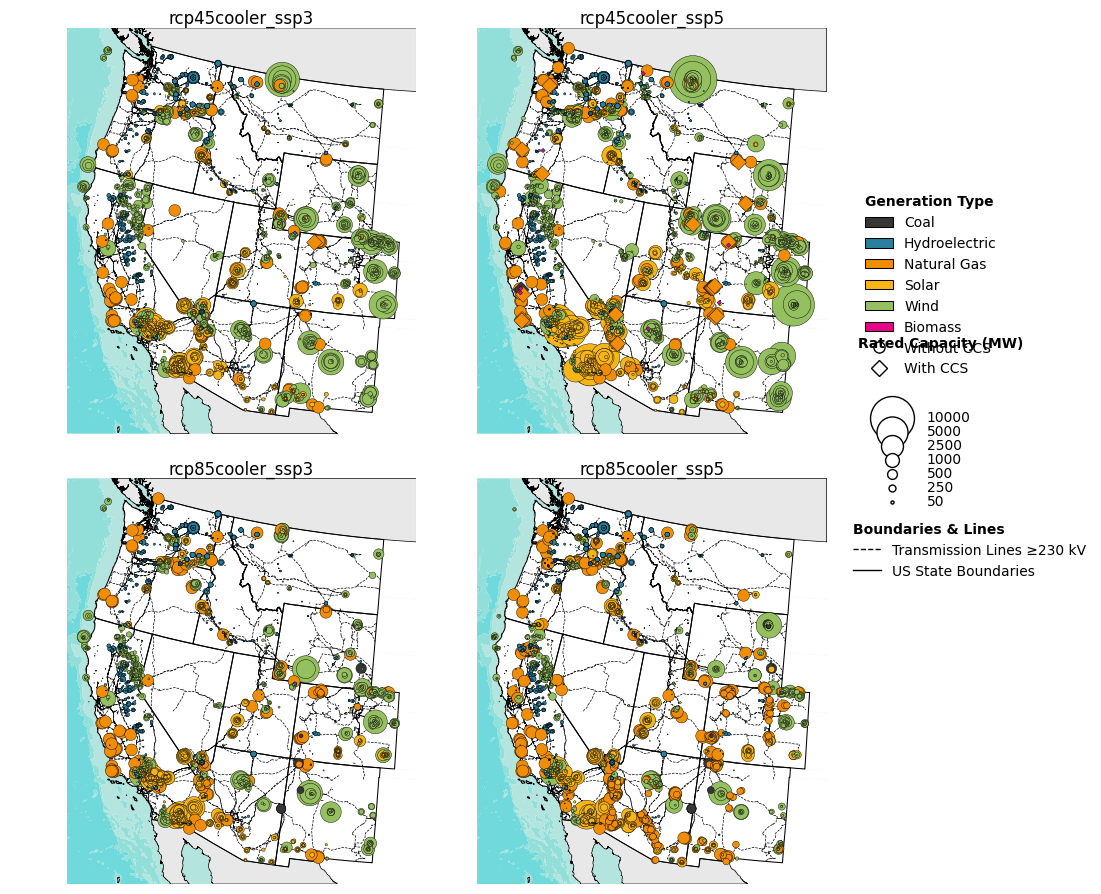

In [7]:
plot_scenario_list = [
    'rcp45cooler_ssp3',
     'rcp45cooler_ssp5',
     'rcp85cooler_ssp3',
     'rcp85cooler_ssp5']

fig = plt.figure()
fig.set_figheight(12)
fig.set_figwidth(13)

spec = GridSpec(ncols=5, 
                nrows=5,
                width_ratios=[.07, 1, .01, 1, .4], 
                wspace=0,
                hspace=.3, 
                height_ratios=[.2, .4, 2.7, 2.7, .4])

ax1a = fig.add_subplot(spec[1:3, 1])
ax1b = fig.add_subplot(spec[1:3, 3])

ax_row1 = fig.add_subplot(spec[1:3,0]) # ssp
ax_row2 = fig.add_subplot(spec[3:, 0]) # ssp

ax2a = fig.add_subplot(spec[3:, 1])
ax2b = fig.add_subplot(spec[3:, 3])

ax_leg1 = fig.add_subplot(spec[2, 4]) 
ax_leg2 = fig.add_subplot(spec[2:3, 4])
ax_leg3 = fig.add_subplot(spec[2:4, 4])

ax_list = [ax1a, ax1b, ax2a, ax2b]

my_scale = 10

for index, scenario in enumerate(plot_scenario_list):
    
    a = ax_list[index]
    
    gdf_plot = data[data.scenario == scenario].copy()
    gdf_plot = gdf_plot.sort_values(by='unit_size_mw', ascending=False)
    gdf_plot_ccs = gdf_plot[gdf_plot.tech_simple.str.contains('CCS')].copy()
    gdf_plot = gdf_plot[~gdf_plot.tech_simple.str.contains('CCS')].copy()
    gdf_plot.plot(ax=a, marker = 'o', lw=.3, facecolor=gdf_plot['color'], edgecolor='black',
                  markersize=gdf_plot['unit_size_mw']/my_scale, zorder=6)
    if gdf_plot_ccs.empty:
        pass
    else:
        gdf_plot_ccs.plot(ax=a, marker = 'D', lw=.3, facecolor=gdf_plot_ccs['color'], 
                          edgecolor='black', markersize=gdf_plot_ccs['unit_size_mw']/my_scale, zorder=6)
    
    wecc.boundary.plot(ax=a, color = 'black', lw=.75, zorder=5)
    state.plot(ax=a, color='white', alpha=1, zorder=3) #f7f7f7
    wecc.plot(ax=a, color = 'white', lw=.75, zorder=4)
    
    transmission_230.plot(ax=a, lw=.5, color='black', linestyle='dashed', zorder=4)  
    na_shape2.plot(ax=a, color='#e8e8e8', alpha=1, zorder=3)
    na_shape2.boundary.plot(ax=a, color='black', zorder=4, lw=.5)
    
    basemap_wecc.plot(ax=a, color=basemap_wecc.color, zorder=1)
    a.set_axis_off()
    a.set_xlim(xMin, xMax)
    a.set_ylim(yMin, yMax)

    # Remove tick marks and labels
    a.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    a.spines['top'].set_visible(True)
    a.spines['right'].set_visible(True)
    a.spines['bottom'].set_visible(True)
    a.spines['left'].set_visible(True)

    a.set_facecolor('#b3e4de') 
    title = scenario
    a.set_title(title, loc='center', y=.99)#.94)


# generation type legend
first_legend = ax_leg1.legend(handles=legend_elements, title='Generation Type', title_fontproperties={'weight':'bold'},
                              bbox_to_anchor=(.95, .8), frameon=False,alignment='left',
                            )
ax_leg1.set_axis_off()

for area in sorted([50/my_scale, 250/my_scale, 500/my_scale, 1000/my_scale,2500/my_scale, 5000/my_scale, 10000/my_scale], reverse=True):
    ax_leg2.scatter([], [], c='white', s=area, label=str(int(area*my_scale)),edgecolors='black')
  
legend2 = ax_leg2.legend(frameon=False, labelspacing=0, title='Rated Capacity (MW)',
                           title_fontproperties={'weight':'bold', 'size':10}, 
                           handletextpad=1.5,
                        bbox_to_anchor=(.65, -.06), loc="center", alignment='left', fontsize=10)
legend2.get_title().set_position((-20, 60))

ax_leg2.set_axis_off()

# boundary legend
bound_legend = ax_leg3.legend(handles=boundary_legend_elements, title='Boundaries & Lines', title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',bbox_to_anchor=(1.5, .42), frameon=False,)
ax_leg3.set_axis_off()

for a in [ax_row1, ax_row2]:
    a.set_axis_off()

plt.savefig(os.path.join(fig_dir, 'fig4.png'), dpi = 400, bbox_inches = 'tight')

plt.show()

### Supplemental Figure 3

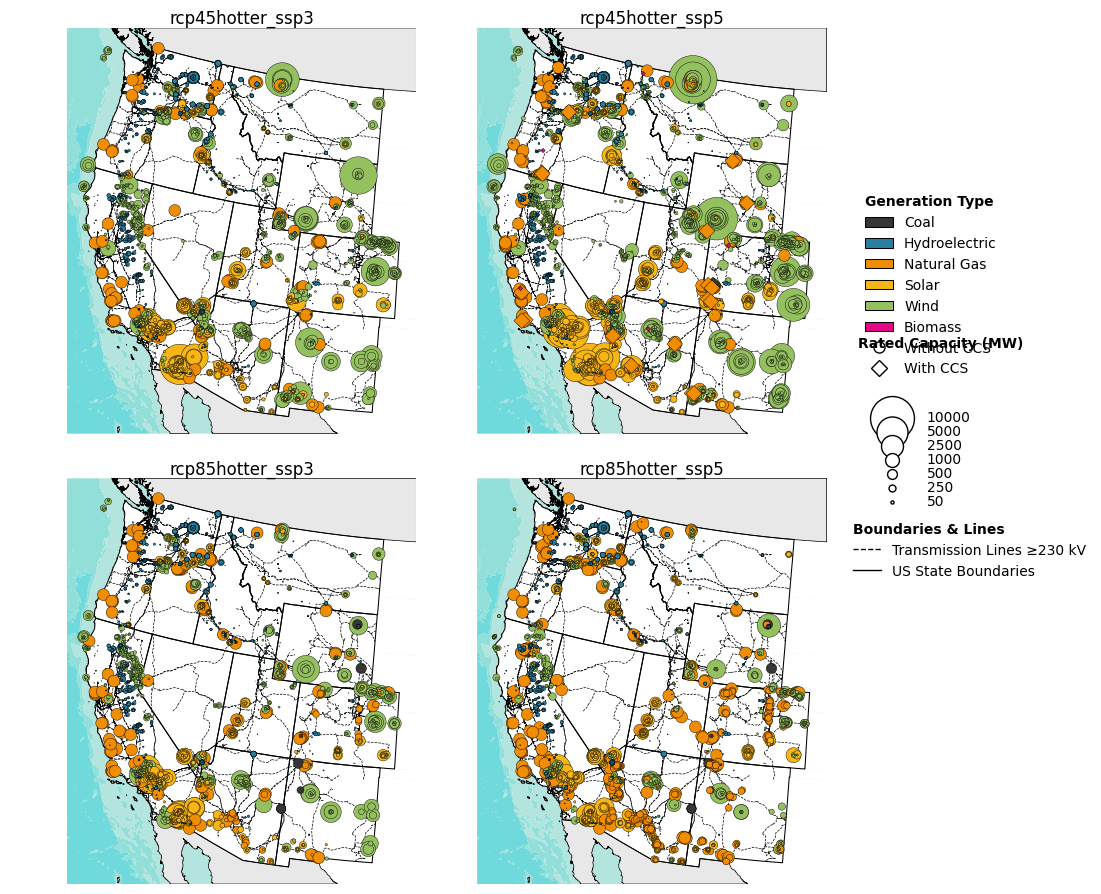

In [8]:
plot_scenario_list = [
    'rcp45hotter_ssp3',
     'rcp45hotter_ssp5',
     'rcp85hotter_ssp3',
     'rcp85hotter_ssp5']

fig = plt.figure()
fig.set_figheight(12)
fig.set_figwidth(13)

spec = GridSpec(ncols=5, 
                nrows=5,
                width_ratios=[.07, 1, .01, 1, .4], 
                wspace=0,
                hspace=.3, 
                height_ratios=[.2, .4, 2.7, 2.7, .4])

ax1a = fig.add_subplot(spec[1:3, 1])
ax1b = fig.add_subplot(spec[1:3, 3])

ax_row1 = fig.add_subplot(spec[1:3,0]) # ssp
ax_row2 = fig.add_subplot(spec[3:, 0]) # ssp

ax2a = fig.add_subplot(spec[3:, 1])
ax2b = fig.add_subplot(spec[3:, 3])

ax_leg1 = fig.add_subplot(spec[2, 4]) 
ax_leg2 = fig.add_subplot(spec[2:3, 4])
ax_leg3 = fig.add_subplot(spec[2:4, 4])

ax_list = [ax1a, ax1b, ax2a, ax2b]

my_scale = 10

for index, scenario in enumerate(plot_scenario_list):
    
    a = ax_list[index]
    
    gdf_plot = data[data.scenario == scenario].copy()
    gdf_plot = gdf_plot.sort_values(by='unit_size_mw', ascending=False)
    gdf_plot_ccs = gdf_plot[gdf_plot.tech_simple.str.contains('CCS')].copy()
    gdf_plot = gdf_plot[~gdf_plot.tech_simple.str.contains('CCS')].copy()
    gdf_plot.plot(ax=a, marker = 'o', lw=.3, facecolor=gdf_plot['color'], edgecolor='black',
                  markersize=gdf_plot['unit_size_mw']/my_scale, zorder=6)
    if gdf_plot_ccs.empty:
        pass
    else:
        gdf_plot_ccs.plot(ax=a, marker = 'D', lw=.3, facecolor=gdf_plot_ccs['color'], 
                          edgecolor='black', markersize=gdf_plot_ccs['unit_size_mw']/my_scale, zorder=6)
    
    wecc.boundary.plot(ax=a, color = 'black', lw=.75, zorder=5)
    state.plot(ax=a, color='white', alpha=1, zorder=3) #f7f7f7
    wecc.plot(ax=a, color = 'white', lw=.75, zorder=4)
    
    transmission_230.plot(ax=a, lw=.5, color='black', linestyle='dashed', zorder=4)  
    na_shape2.plot(ax=a, color='#e8e8e8', alpha=1, zorder=3)
    na_shape2.boundary.plot(ax=a, color='black', zorder=4, lw=.5)
    
    basemap_wecc.plot(ax=a, color=basemap_wecc.color, zorder=1)
    a.set_axis_off()
    a.set_xlim(xMin, xMax)
    a.set_ylim(yMin, yMax)

    # Remove tick marks and labels
    a.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    a.spines['top'].set_visible(True)
    a.spines['right'].set_visible(True)
    a.spines['bottom'].set_visible(True)
    a.spines['left'].set_visible(True)

    a.set_facecolor('#b3e4de') 
    title = scenario
    a.set_title(title, loc='center', y=.99)#.94)


# generation type legend
first_legend = ax_leg1.legend(handles=legend_elements, title='Generation Type', title_fontproperties={'weight':'bold'},
                              bbox_to_anchor=(.95, .8), frameon=False,alignment='left',
                            )
ax_leg1.set_axis_off()

for area in sorted([50/my_scale, 250/my_scale, 500/my_scale, 1000/my_scale,2500/my_scale, 5000/my_scale, 10000/my_scale], reverse=True):
    ax_leg2.scatter([], [], c='white', s=area, label=str(int(area*my_scale)),edgecolors='black')
  
legend2 = ax_leg2.legend(frameon=False, labelspacing=0, title='Rated Capacity (MW)',
                           title_fontproperties={'weight':'bold', 'size':10}, 
                           handletextpad=1.5,
                        bbox_to_anchor=(.65, -.06), loc="center", alignment='left', fontsize=10)
legend2.get_title().set_position((-20, 60))

ax_leg2.set_axis_off()

# boundary legend
bound_legend = ax_leg3.legend(handles=boundary_legend_elements, title='Boundaries & Lines', title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',bbox_to_anchor=(1.5, .42), frameon=False,)
ax_leg3.set_axis_off()

for a in [ax_row1, ax_row2]:
    a.set_axis_off()

plt.savefig(os.path.join(fig_dir, 'si_3.png'), dpi = 400, bbox_inches = 'tight')

plt.show()